In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

print("Libraries imported successfully!")

Libraries imported successfully!


Original Data Shape - Images: (70000, 784), Labels: (70000,)
Training set: 49000 samples
Validation set: 7000 samples
Test set: 14000 samples


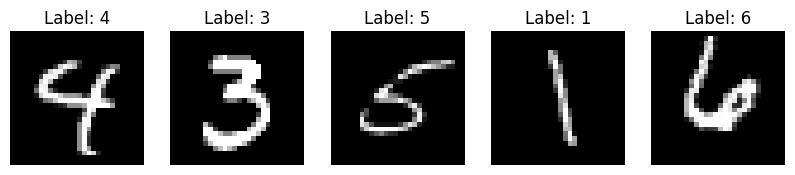

In [3]:
print("Downloading MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, parser='auto')
X = mnist.data.to_numpy().astype(np.float32)
y = mnist.target.to_numpy().astype(np.int64)

print(f"Original Data Shape - Images: {X.shape}, Labels: {y.shape}")

X = X / 255.0
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.125, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.show()

In [4]:
class ScratchANN:
    def __init__(self, input_size=784, hidden_size=128, output_size=10, learning_rate=0.01):
        self.lr = learning_rate
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
        self.b2 = np.zeros((1, output_size))

    def relu(self, Z):
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        return Z > 0

    def softmax(self, Z):
        exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    def forward_propagation(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.relu(self.Z1)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.softmax(self.Z2)
        return self.A2

    def compute_loss(self, y_true, y_pred):
        m = y_true.shape[0]
        log_likelihood = -np.log(y_pred[np.arange(m), y_true] + 1e-8)
        loss = np.sum(log_likelihood) / m
        return loss

    def back_propagation(self, X, y_true, y_pred):
        m = X.shape[0]
        y_one_hot = np.zeros((m, 10))
        y_one_hot[np.arange(m), y_true] = 1

        dZ2 = self.A2 - y_one_hot
        dW2 = np.dot(self.A1.T, dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        dZ1 = np.dot(dZ2, self.W2.T) * self.relu_derivative(self.Z1)
        dW1 = np.dot(X.T, dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

    def fit(self, X_train, y_train, X_val, y_val, epochs=10, batch_size=64):
        train_loss_history, val_loss_history = [], []
        train_acc_history, val_acc_history = [], []

        num_samples = X_train.shape[0]

        for epoch in range(epochs):
            indices = np.arange(num_samples)
            np.random.shuffle(indices)
            X_train_shuffled = X_train[indices]
            y_train_shuffled = y_train[indices]

            for i in range(0, num_samples, batch_size):
                X_batch = X_train_shuffled[i:i+batch_size]
                y_batch = y_train_shuffled[i:i+batch_size]
                preds = self.forward_propagation(X_batch)
                self.back_propagation(X_batch, y_batch, preds)

            train_preds = self.forward_propagation(X_train)
            train_loss = self.compute_loss(y_train, train_preds)
            train_acc = accuracy_score(y_train, np.argmax(train_preds, axis=1))

            val_preds = self.forward_propagation(X_val)
            val_loss = self.compute_loss(y_val, val_preds)
            val_acc = accuracy_score(y_val, np.argmax(val_preds, axis=1))

            train_loss_history.append(train_loss)
            val_loss_history.append(val_loss)
            train_acc_history.append(train_acc)
            val_acc_history.append(val_acc)

            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} - Train Acc: {train_acc*100:.2f}% | Val Loss: {val_loss:.4f} - Val Acc: {val_acc*100:.2f}%")

        return train_loss_history, val_loss_history, train_acc_history, val_acc_history

    def predict(self, X):
        probs = self.forward_propagation(X)
        return np.argmax(probs, axis=1)

In [5]:
# Experiment 1: Hidden Size = 64, Learning Rate = 0.05, Batch Size = 64
print("--- Experiment 1: LR=0.05, Hidden=64, Batch=64 ---")
np.random.seed(42)
ann_exp1 = ScratchANN(input_size=784, hidden_size=64, output_size=10, learning_rate=0.05)
hist1_train_loss, hist1_val_loss, hist1_train_acc, hist1_val_acc = ann_exp1.fit(
    X_train, y_train, X_val, y_val, epochs=10, batch_size=64
)

# Experiment 2: Hidden Size = 128, Learning Rate = 0.1, Batch Size = 32
print("\n--- Experiment 2: LR=0.1, Hidden=128, Batch=32 ---")
np.random.seed(42)
ann_exp2 = ScratchANN(input_size=784, hidden_size=128, output_size=10, learning_rate=0.1)
hist2_train_loss, hist2_val_loss, hist2_train_acc, hist2_val_acc = ann_exp2.fit(
    X_train, y_train, X_val, y_val, epochs=10, batch_size=32
)

# Experiment 3: Hidden Size = 256, Learning Rate = 0.01, Batch Size = 128
print("\n--- Experiment 3: LR=0.01, Hidden=256, Batch=128 ---")
np.random.seed(42)
ann_exp3 = ScratchANN(input_size=784, hidden_size=256, output_size=10, learning_rate=0.01)
hist3_train_loss, hist3_val_loss, hist3_train_acc, hist3_val_acc = ann_exp3.fit(
    X_train, y_train, X_val, y_val, epochs=10, batch_size=128
)

--- Experiment 1: LR=0.05, Hidden=64, Batch=64 ---
Epoch 1/10 | Train Loss: 0.3104 - Train Acc: 91.20% | Val Loss: 0.3295 - Val Acc: 90.69%
Epoch 2/10 | Train Loss: 0.2567 - Train Acc: 92.67% | Val Loss: 0.2759 - Val Acc: 92.10%
Epoch 3/10 | Train Loss: 0.2156 - Train Acc: 93.82% | Val Loss: 0.2397 - Val Acc: 92.97%
Epoch 4/10 | Train Loss: 0.1964 - Train Acc: 94.31% | Val Loss: 0.2247 - Val Acc: 93.00%
Epoch 5/10 | Train Loss: 0.1705 - Train Acc: 95.08% | Val Loss: 0.1999 - Val Acc: 94.00%
Epoch 6/10 | Train Loss: 0.1574 - Train Acc: 95.43% | Val Loss: 0.1842 - Val Acc: 94.57%
Epoch 7/10 | Train Loss: 0.1406 - Train Acc: 95.91% | Val Loss: 0.1703 - Val Acc: 95.00%
Epoch 8/10 | Train Loss: 0.1307 - Train Acc: 96.26% | Val Loss: 0.1636 - Val Acc: 95.09%
Epoch 9/10 | Train Loss: 0.1190 - Train Acc: 96.55% | Val Loss: 0.1509 - Val Acc: 95.47%
Epoch 10/10 | Train Loss: 0.1119 - Train Acc: 96.76% | Val Loss: 0.1444 - Val Acc: 95.73%

--- Experiment 2: LR=0.1, Hidden=128, Batch=32 ---
Epoch 

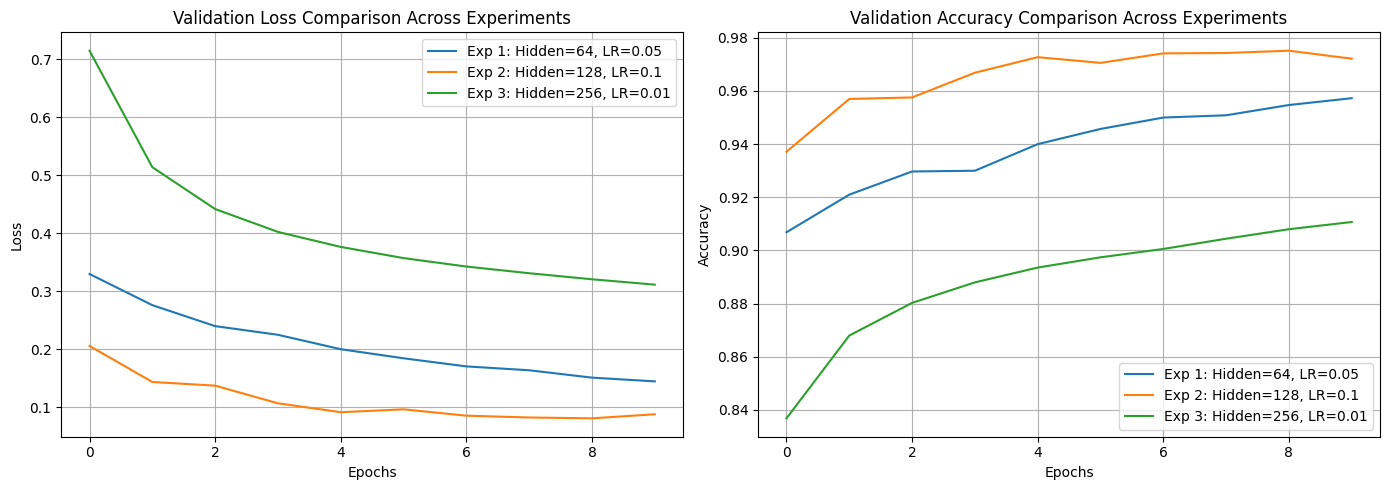

In [6]:
plt.figure(figsize=(14, 5))

# Plot Validation Loss Comparison
plt.subplot(1, 2, 1)
plt.plot(hist1_val_loss, label='Exp 1: Hidden=64, LR=0.05')
plt.plot(hist2_val_loss, label='Exp 2: Hidden=128, LR=0.1')
plt.plot(hist3_val_loss, label='Exp 3: Hidden=256, LR=0.01')
plt.title('Validation Loss Comparison Across Experiments')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Validation Accuracy Comparison
plt.subplot(1, 2, 2)
plt.plot(hist1_val_acc, label='Exp 1: Hidden=64, LR=0.05')
plt.plot(hist2_val_acc, label='Exp 2: Hidden=128, LR=0.1')
plt.plot(hist3_val_acc, label='Exp 3: Hidden=256, LR=0.01')
plt.title('Validation Accuracy Comparison Across Experiments')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

--- Final Model Evaluation on Test Set ---
Test Accuracy: 97.19%

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1343
           1       0.98      0.99      0.99      1600
           2       0.97      0.97      0.97      1380
           3       0.99      0.95      0.97      1433
           4       0.98      0.96      0.97      1295
           5       0.98      0.97      0.97      1273
           6       0.98      0.98      0.98      1396
           7       0.97      0.97      0.97      1503
           8       0.96      0.96      0.96      1357
           9       0.93      0.98      0.95      1420

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



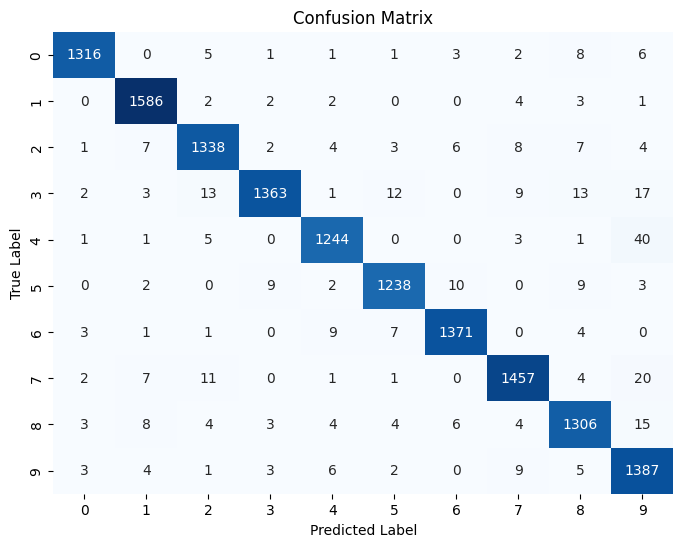

Total misclassified images in test set: 394


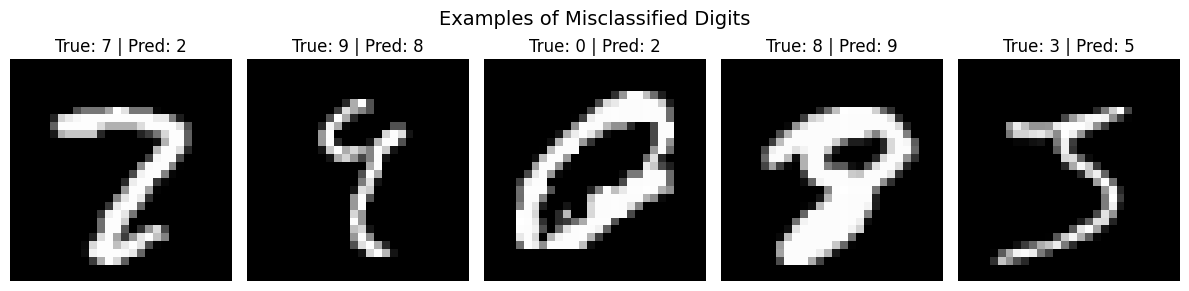

In [7]:
# Using Experiment 2 as our final model since higher learning rate and capacity usually converge well
best_model = ann_exp2
y_pred = best_model.predict(X_test)

# Comprehensive Evaluation Metrics
print("--- Final Model Evaluation on Test Set ---")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Visualize Misclassified Digits
misclassified_indices = np.where(y_pred != y_test)[0]
print(f"Total misclassified images in test set: {len(misclassified_indices)}")

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, ax in enumerate(axes):
    idx = misclassified_indices[i]
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f"True: {y_test[idx]} | Pred: {y_pred[idx]}")
    ax.axis('off')
plt.suptitle("Examples of Misclassified Digits", fontsize=14)
plt.tight_layout()
plt.show()